In [ ]:
import sys
import numpy as np

In [ ]:
from astropy import units as u
from astropy.coordinates import SkyCoord
from astropy.io import fits
from astropy.wcs import WCS

In [4]:
import matplotlib
#matplotlib.use('Agg') # Must be before importing matplotlib.pyplot or pylab!
import matplotlib.pyplot as plt
import matplotlib.path as mpath
import matplotlib.patheffects as path_effects
import matplotlib.patheffects as patheffects
import matplotlib.patches as mpatches
import matplotlib.colors as colors
from matplotlib.colors import LogNorm

In [5]:
import healpy as hp
import cmasher as cmr
from tqdm import tqdm

In [6]:
sys.path.append('/Users/soler/Documents/PYTHON/astroHOG/')
from astroHOGhp import *

In [8]:
nside=256

In [10]:
map1=np.zeros(hp.nside2npix(nside))
ipix=np.arange(hp.nside2npix(nside))
map1[(np.abs(glat) < 10.).nonzero()]=1.0

In [13]:
glon, glat = hp.pixelfunc.pix2ang(nside, ipix, nest=False, lonlat=True)

In [58]:
hdul=fits.open("../data/NHI_HPX.fits")
map1=hdul[1].data['NHI']

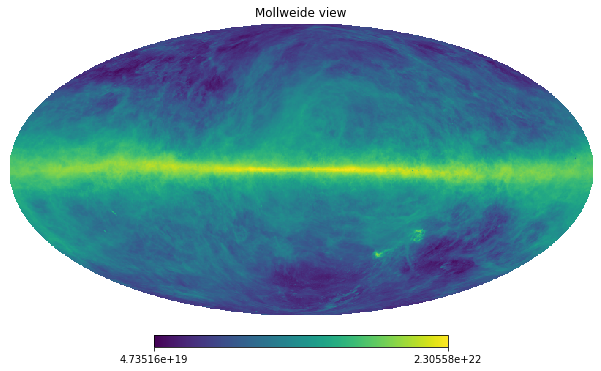

In [61]:
hp.mollview(map1, norm='log')

In [62]:
output=gradienthp(map1, niter=3, ksz=1.0)
dmap1dtheta=output['dtheta']
dmap1dphi=output['dphi']
smap1=output['smap']
gradmap1=output['gradmap']

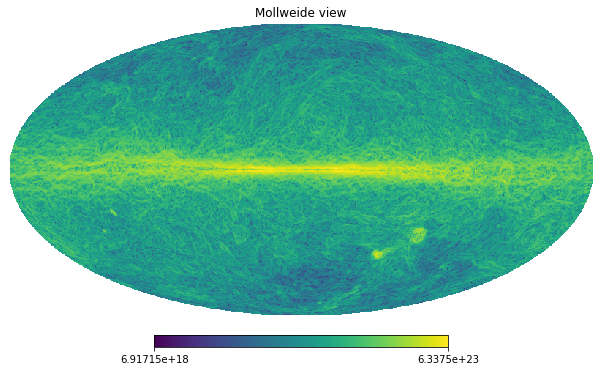

In [64]:
hp.mollview(gradmap1, norm='log')

In [65]:
hdul=fits.open("../data/COM_CompMap_Dust-GNILC-Model-Opacity_2048_R2.01.fits")
map2=hdul[1].data['TAU353']
s_map2=hdul[1].data['ERR_TAU']

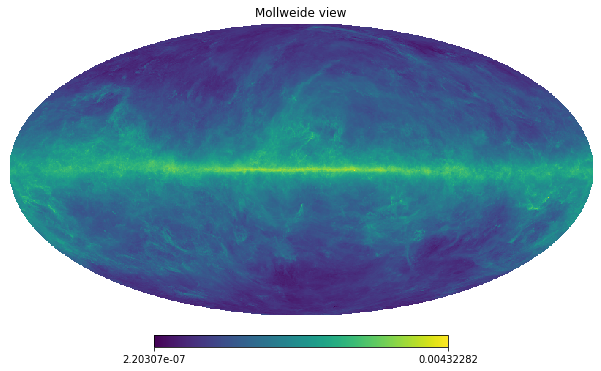

In [66]:
hp.mollview(map2, norm='log')

In [44]:
output=gradienthp(map2, niter=3, ksz=2.0)

In [67]:
dmap2dtheta=output['dtheta']
dmap2dphi=output['dphi']
smap2=output['smap']
gradmap2=output['gradmap']

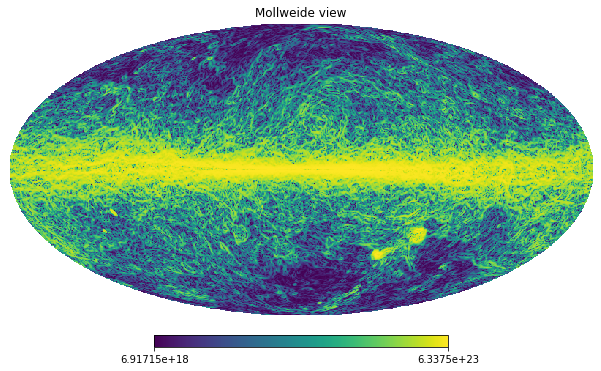

In [69]:
hp.mollview(gradmap2, norm='hist')